# LangGraph MCP (Model Context Protocol) 튜토리얼

이 튜토리얼에서는 LangGraph와 MCP(Model Context Protocol)를 통합하여 강력한 AI 에이전트를 구축하는 방법을 배웁니다. MCP는 AI 애플리케이션에서 도구(Tool)와 컨텍스트를 표준화된 방식으로 제공하는 오픈 프로토콜입니다. MCP를 활용하면 다양한 외부 서비스와 데이터를 일관된 인터페이스로 LLM에 연결할 수 있습니다.

> 참고 문서: [Model Context Protocol 공식 문서](https://modelcontextprotocol.io/introduction)

## 학습 목표

- MCP의 개념과 아키텍처를 이해합니다
- MultiServerMCPClient를 사용하여 다중 서버를 관리하는 방법을 학습합니다
- create_agent 및 ToolNode와 MCP를 통합하는 방법을 익힙니다
- 실전 예제를 통해 복잡한 에이전트를 구축합니다

## 목차

1. MCP 개요 및 설치
2. 기본 MCP 서버 생성
3. MultiServerMCPClient 설정
4. Agent와 MCP 통합
5. ToolNode와 MCP 통합
6. 외부 MCP 서버에서 3rd Party 도구 사용하기

## 환경 설정

튜토리얼을 시작하기 전에 필요한 환경을 설정합니다. `dotenv`를 사용하여 API 키를 로드하고, `langchain_teddynote`의 로깅 기능을 활성화하여 LangSmith에서 실행 추적을 확인할 수 있도록 합니다.

LangSmith 추적을 활성화하면 에이전트의 추론 과정, 도구 호출, 응답 생성 등을 시각적으로 디버깅할 수 있어 개발에 큰 도움이 됩니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 추적을 위한 프로젝트 이름 설정
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


## Part 1: MCP 기본 개념

### MCP(Model Context Protocol)란?

MCP는 애플리케이션이 언어 모델에 도구와 컨텍스트를 제공하는 방법을 표준화한 오픈 프로토콜입니다. 이 프로토콜을 사용하면 다양한 서비스와 도구를 일관된 방식으로 LLM에 연결할 수 있습니다. 기존에는 각 도구마다 개별적인 연동 방식이 필요했지만, MCP를 통해 하나의 표준 인터페이스로 통합할 수 있게 되었습니다.

### 주요 특징

- **표준화된 도구 인터페이스**: 일관된 방식으로 도구를 정의하고 사용할 수 있습니다
- **다양한 전송 메커니즘**: stdio, HTTP, WebSocket 등 여러 통신 방식을 지원합니다
- **동적 도구 검색**: 런타임에 도구를 자동으로 검색하고 로드할 수 있습니다
- **확장 가능한 아키텍처**: 여러 서버를 동시에 연결하여 사용할 수 있습니다

### 설치

MCP를 사용하기 위해 필요한 패키지를 설치합니다. `langchain-mcp-adapters` 패키지는 LangChain 에이전트가 MCP 서버에 정의된 도구를 사용할 수 있도록 해주는 어댑터 라이브러리입니다. 이 패키지를 통해 MCP 서버에서 제공하는 도구를 LangChain/LangGraph 에이전트에서 직접 활용할 수 있습니다.

아래 코드는 튜토리얼에서 사용할 주요 패키지들을 import합니다.

In [2]:
import nest_asyncio
from typing import List, Dict, Any

from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# MCP 클라이언트: 여러 MCP 서버에 연결하여 도구를 가져옵니다
from langchain_mcp_adapters.client import MultiServerMCPClient

# 비동기 호출을 활성화합니다 (Jupyter 환경에서 필요)
nest_asyncio.apply()

---

## Part 2: 기본 MCP 서버 생성

MCP 서버는 도구를 제공하는 독립적인 프로세스입니다. FastMCP를 사용하면 Python으로 간단하게 MCP 서버를 만들 수 있습니다. MCP 서버는 클라이언트의 요청을 받아 도구를 실행하고 결과를 반환하는 역할을 수행합니다. 이 튜토리얼에서는 미리 준비된 MCP 서버들을 사용합니다.

### 제공되는 MCP 서버

이 튜토리얼에서 사용하는 MCP 서버 파일들은 `server/` 디렉토리에 위치해 있습니다:

| 파일명 | 설명 | 전송 방식 |
|--------|------|----------|
| `mcp_server_local.py` | 날씨 정보를 제공하는 로컬 서버 | stdio |
| `mcp_server_remote.py` | 현재 시간을 제공하는 원격 서버 | HTTP |
| `mcp_server_rag.py` | PDF 문서 검색 기능을 제공하는 RAG 서버 | stdio |

각 서버는 `FastMCP`를 사용하여 구현되어 있으며, 도구(Tool)를 정의하고 클라이언트 요청에 응답합니다.

---

## Part 3: MultiServerMCPClient 설정

`MultiServerMCPClient`는 여러 MCP 서버를 동시에 관리하고 연결할 수 있는 클라이언트입니다. 각 서버에서 제공하는 도구들을 통합하여 하나의 도구 목록으로 사용할 수 있습니다. 이를 통해 서로 다른 기능을 가진 여러 MCP 서버의 도구를 단일 에이전트에서 활용할 수 있습니다.

### 지원하는 전송 방식

- **stdio**: 클라이언트가 서버를 서브프로세스로 실행하고 표준 입출력을 통해 통신합니다. 로컬 개발에 적합합니다.
- **streamable_http**: 서버가 독립적인 프로세스로 실행되어 HTTP 요청을 처리합니다. 원격 연결에 적합합니다.

아래 코드는 MCP 클라이언트를 설정하고 서버에서 도구를 가져오는 헬퍼 함수를 정의합니다.

In [3]:
async def setup_mcp_client(server_configs: dict):
    """MCP 클라이언트를 설정하고 도구를 가져옵니다.

    Args:
        server_configs: 서버 구성 딕셔너리. 각 서버의 이름을 키로,
                       연결 정보(command, args, transport 또는 url)를 값으로 가집니다.

    Returns:
        tuple: (MCP 클라이언트, 로드된 도구 목록)
    """
    # MCP 클라이언트 생성
    client = MultiServerMCPClient(server_configs)

    # 서버에 연결하여 도구 목록을 가져옵니다
    tools = await client.get_tools()

    # 로드된 도구 목록을 출력합니다
    print(f"[MCP] {len(tools)}개의 도구가 로드되었습니다:")
    for tool in tools:
        print(f"  - {tool.name}")

    return client, tools

### stdio 전송 방식 사용

stdio 전송 방식은 MCP 클라이언트가 서버를 서브프로세스로 직접 실행하여 표준 입출력(stdin/stdout)을 통해 통신하는 방식입니다. 별도의 서버 실행 없이 클라이언트가 자동으로 프로세스를 관리하므로 로컬 개발 환경에서 가장 편리하게 사용할 수 있습니다.

아래 코드는 날씨 MCP 서버를 stdio 방식으로 연결하고 도구를 로드합니다.

In [4]:
# 날씨 서버 구성 정의 (stdio 전송 방식)
server_configs = {
    "weather": {
        "command": "uv",  # uv 패키지 매니저 사용
        "args": ["run", "python", "server/mcp_server_local.py"],
        "transport": "stdio",  # 표준 입출력을 통한 통신
    },
}

# MCP 클라이언트 생성 및 도구 로드
client, tools = await setup_mcp_client(server_configs=server_configs)

[MCP] 1개의 도구가 로드되었습니다:
  - get_weather


아래 코드는 MCP 도구를 사용하는 에이전트를 생성합니다. `create_agent`는 LangChain v1에서 제공하는 에이전트 생성 함수로, LLM과 도구 목록을 전달하면 추론-행동 루프를 자동으로 구현합니다.

> 참고: LangGraph v1에서 기존의 `create_react_agent`는 deprecated 되었으며, `langchain.agents.create_agent`를 사용하는 것이 권장됩니다.

In [5]:
# LLM 설정
# OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능
llm = init_chat_model("claude-sonnet-4-5", temperature=0)

# 에이전트 생성: MCP 도구를 사용하는 에이전트
agent = create_agent(
    llm,
    tools,
    checkpointer=InMemorySaver(),  # 대화 상태를 메모리에 저장
)

아래 코드는 생성된 에이전트를 사용하여 날씨 정보를 요청합니다. `astream_graph` 함수를 사용하면 에이전트의 실행 과정을 스트리밍으로 확인할 수 있습니다.

In [6]:
# 스트리밍 헬퍼 함수와 UUID 생성 함수를 import합니다
from langchain_teddynote.messages import astream_graph, random_uuid
from langchain_core.runnables import RunnableConfig

# 대화 스레드 ID를 설정합니다
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 에이전트 실행: 날씨 정보 요청
response = await astream_graph(
    agent,
    inputs={"messages": [("human", "안녕하세요. 서울의 날씨를 알려주세요.")]},
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
It's always Sunny in 서울
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! 서울의 현재 날씨를 확인했습니다.

**서울의 날씨: 맑음 ☀️**

서울은 항상 화창한 날씨네요! 좋은 하루 보내세요!

### HTTP 전송 방식 사용

원격 서버나 HTTP 엔드포인트를 사용하는 경우 `streamable_http` 전송 방식을 사용합니다. 이 방식은 서버가 별도의 프로세스로 실행 중이어야 합니다. stdio 방식과 달리 클라이언트가 서버를 직접 관리하지 않으므로, 사전에 서버가 실행 상태여야 연결이 가능합니다.

**사전 준비**: 아래 코드를 실행하기 전에 별도의 터미널에서 Remote MCP 서버를 먼저 구동해야 합니다.

```bash
uv run python server/mcp_server_remote.py
```

아래 코드는 HTTP 기반 MCP 서버에 연결하는 예제입니다.

In [8]:
# HTTP 기반 MCP 서버 설정
http_server_config = {
    "current_time": {
        "url": "http://127.0.0.1:8002/mcp",  # HTTP 엔드포인트 URL
        "transport": "streamable_http",  # HTTP 스트리밍 전송 방식
    },
}

# MCP 클라이언트 생성 및 HTTP 서버 도구 로드
client, http_tools = await setup_mcp_client(server_configs=http_server_config)

[MCP] 1개의 도구가 로드되었습니다:
  - get_current_time


아래 코드는 HTTP 전송 방식으로 연결된 MCP 도구를 사용하는 에이전트를 생성합니다.

In [9]:
# LLM 설정
# OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능
llm = init_chat_model("claude-sonnet-4-5", temperature=0)

# HTTP 도구를 사용하는 에이전트 생성
agent = create_agent(
    llm,
    http_tools,
    checkpointer=InMemorySaver(),
)

아래 코드는 HTTP 기반 MCP 에이전트를 실행하여 현재 시간을 요청합니다.

In [10]:
# 새로운 대화 스레드 설정
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 에이전트 실행: 현재 시간 요청
response = await astream_graph(
    agent,
    inputs={"messages": [("human", "안녕하세요. 현재 시간을 알려주세요.")]},
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Current time in Asia/Seoul is: 2026-03-18 21:43:14 KST
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! 

현재 한국 시간은 **2026년 3월 18일 수요일 오후 9시 43분 14초**입니다.

### MCP Inspector 사용

MCP Inspector는 MCP 서버를 테스트하고 디버깅할 수 있는 웹 기반 도구입니다. 브라우저에서 서버의 도구 목록을 확인하고, 직접 도구를 호출하여 결과를 확인할 수 있습니다. 개발 과정에서 MCP 서버가 올바르게 동작하는지 빠르게 검증할 때 매우 유용합니다.

다음 명령어를 터미널에서 실행하면 MCP Inspector가 시작됩니다:

```bash
npx @modelcontextprotocol/inspector
```

아래 이미지는 MCP Inspector의 인터페이스 예시입니다.

![mcp_inspector](./assets/mcp-inspector.png)

### RAG MCP 서버 사용

RAG(Retrieval-Augmented Generation, 검색 증강 생성)는 외부 문서에서 관련 정보를 검색하여 LLM의 응답을 보강하는 기법입니다. MCP 서버를 통해 RAG 기능을 제공하면, 에이전트가 PDF 문서 등의 외부 데이터에서 필요한 정보를 검색하여 보다 정확한 답변을 생성할 수 있습니다.

아래 코드는 RAG 기능을 제공하는 MCP 서버에 연결하고 도구를 로드합니다.

In [11]:
# RAG(검색 증강 생성) MCP 서버 설정
# PDF 문서에서 정보를 검색하는 기능을 제공합니다
rag_server_config = {
    "rag": {
        "command": "uv",
        "args": ["run", "python", "server/mcp_server_rag.py"],
        "transport": "stdio",
    },
}

# MCP 클라이언트 생성 및 RAG 도구 로드
client, rag_tools = await setup_mcp_client(server_configs=rag_server_config)

[MCP] 1개의 도구가 로드되었습니다:
  - retrieve


아래 코드는 RAG 도구를 사용하는 에이전트를 생성합니다.

In [12]:
# LLM 설정
# OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능
llm = init_chat_model("claude-sonnet-4-5", temperature=0)

# RAG 도구를 사용하는 에이전트 생성
rag_agent = create_agent(
    llm,
    rag_tools,
    checkpointer=InMemorySaver(),
)

아래 코드는 RAG 에이전트를 실행하여 PDF 문서에서 삼성전자의 생성형 AI 관련 정보를 검색합니다.

In [13]:
# 새로운 대화 스레드 설정
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# RAG 에이전트 실행: PDF 문서에서 정보 검색
_ = await astream_graph(
    rag_agent,
    inputs={
        "messages": [
            (
                "human",
                "삼성전자가 개발한 생성형 AI 의 이름은? mcp 서버를 사용해서 검색해주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
SPRi AI Brief |
2023-12월호
삼성전자, 자체 개발 생성 AI ‘삼성 가우스’ 공개
KEY Contents
n 삼성전자가 온디바이스에서 작동 가능하며 언어, 코드, 이미지의 3개 모델로 구성된 자체 개발 생성
AI 모델 ‘삼성 가우스’를 공개
n 삼성전자는 삼성 가우스를 다양한 제품에 단계적으로 탑재할 계획으로, 온디바이스 작동이 가능한
삼성 가우스는 외부로 사용자 정보가 유출될 위험이 없다는 장점을 보유
£언어, 코드, 이미지의 3개 모델로 구성된 삼성 가우스, 온디바이스 작동 지원
n 삼성전자가 2023년 11월 8일 열린 ‘삼성 AI 포럼 2023’ 행사에서 자체 개발한 생성 AI 모델
‘삼성 가우스’를 최초 공개
∙ 정규분포 이론을 정립한 천재 수학자 가우스(Gauss)의 이름을 본뜬 삼성 가우스는 다양한 상황에
최적화된 크기의 모델 선택이 가능
∙ 삼성 가우스는 라이선스나 개인정보를 침해하지 않는 안전한 데이터를 통해 학습되었으며,
온디바이스에서 작동하도록 설계되어 외부로 사용자의 정보가 유출되지 않는 장점을 보유
∙ 삼성전자는 삼성 가우스를 활용한 온디바이스 AI 기술도 소개했으며, 생성 AI 모델을 다양한 제품에
단계적으로 탑재할 계획
n 삼성 가우스는 △텍스트를 생성하는 언어모델 △코드를 생성하는 코드 모델 △이미지를 생성하는
이미지 모델의 3개 모델로 구성
∙ 언어 모델은 클라우드와 온디바이스 대상 다양한 모델로 구성되며, 메일 작성, 문서 요약, 번역 업무의
처리를 지원
∙ 코드 모델 기반의 AI 코딩 어시스턴트 ‘코드아이(code.i)’는 대화형 인터페이스로 서비스를 제공하며
사내 소프트웨어 개발에 최적화
∙ 이미지 모델은 창의적인 이미지를 생성하고 기존 이미지를 원하는 대로 바꿀 수 

아래 코드는 동일한 RAG 에이전트로 다른 질문을 실행하여 구글의 Anthropic 투자 금액을 검색합니다.

In [14]:
# 다른 질문으로 RAG 에이전트 테스트
_ = await astream_graph(
    rag_agent,
    inputs={
        "messages": [
            (
                "human",
                "구글이 Anthropic 에 투자하기로 한 금액을 검색해줘",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
∙ 구글은 앤스로픽 외에도 AI 동영상 제작 도구를 개발하는 런웨이(Runway)와 오픈소스 소프트웨어
기업 허깅 페이스(Hugging Face)에도 투자
∙ 구글은 챗GPT의 기반 기술과 직접 경쟁할 수 있는 차세대 LLM ‘제미니(Gemini)’를 포함한 자체 AI
시스템 개발에도 수십억 달러를 투자했으며, 2024년 제미니를 출시할 계획
☞ 출처 : The Wall Street Journal, Google Commits $2 Billion in Funding to AI Startup Anthropic, 2023.10.27.
Bloomberg, AI Startup Anthropic to Use Google Chips in Expanded Partnership, 2023.11.09.
1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육
구글, 앤스로픽에 20억 달러 투자로 생성 AI 협력 강화
KEY Contents
n 구글이 앤스로픽에 최대 20억 달러 투자에 합의하고 5억 달러를 우선 투자했으며, 앤스로픽은
구글과 클라우드 서비스 사용 계약도 체결
n 3대 클라우드 사업자인 구글, 마이크로소프트, 아마존은 차세대 AI 모델의 대표 기업인
앤스로픽 및 오픈AI와 협력을 확대하는 추세
£구글, 앤스로픽에 최대 20억 달러 투자 합의 및 클라우드 서비스 제공
n 구글이 2023년 10월 27일 앤스로픽에 최대 20억 달러를 투자하기로 합의했으며, 이 중 5억
달러를 우선 투자하고 향후 15억 달러를 추가로 투자할 방침
∙ 구글은 2023년 2월 앤스로픽에 이미 5억 5,000만 달러를 투자한 바 있으며, 아마존도 지난 9월
앤스로픽에 최대 40억 달러의 투자 계획을 공개
∙ 한편, 2023년 11월 8일 블룸버

React Agent는 추론(Reason)과 행동(Act)을 반복하는 ReAct 패턴을 구현합니다. LLM이 상황을 분석하고, 필요한 도구를 선택하여 호출하고, 결과를 바탕으로 다음 행동을 결정하는 과정을 자동으로 수행합니다. 이 패턴은 복잡한 작업을 여러 단계로 나누어 처리할 때 특히 효과적입니다.

MCP 도구와 함께 사용하면 다양한 외부 서비스에 접근할 수 있는 강력한 에이전트를 만들 수 있습니다. 여러 MCP 서버의 도구를 하나의 에이전트에 통합하면 복합적인 작업도 단일 에이전트로 처리할 수 있습니다.

> 참고 문서: [LangGraph Agents](https://docs.langchain.com/oss/python/langchain/agents)

아래 코드는 MCP 도구를 사용하는 에이전트를 생성하는 헬퍼 함수를 정의합니다.

In [15]:
async def create_mcp_agent(server_configs: dict):
    """MCP 도구를 사용하는 에이전트를 생성합니다.

    이 함수는 주어진 서버 구성으로 MCP 클라이언트를 생성하고,
    해당 도구들을 사용하는 에이전트를 반환합니다.

    Args:
        server_configs: MCP 서버 구성 딕셔너리

    Returns:
        CompiledStateGraph: 컴파일된 에이전트
    """
    # MCP 클라이언트 생성 및 도구 가져오기
    client, tools = await setup_mcp_client(server_configs=server_configs)

    # LLM 설정
    # OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능
    llm = init_chat_model("claude-sonnet-4-5", temperature=0)

    # 에이전트 생성
    agent = create_agent(
        llm,
        tools,
        checkpointer=InMemorySaver(),
    )

    return agent

아래 코드는 날씨(stdio)와 시간(HTTP) 두 개의 MCP 서버를 동시에 연결하여 다중 서버 에이전트를 생성합니다.

In [16]:
# 다중 MCP 서버 구성: 날씨(stdio) + 시간(HTTP)
server_configs = {
    "weather": {
        "command": "uv",
        "args": ["run", "python", "server/mcp_server_local.py"],
        "transport": "stdio",
    },
    "current_time": {
        "url": "http://127.0.0.1:8002/mcp",
        "transport": "streamable_http",
    },
}

# 다중 MCP 서버를 사용하는 에이전트 생성
agent = await create_mcp_agent(server_configs)

[MCP] 2개의 도구가 로드되었습니다:
  - get_weather
  - get_current_time


아래 코드는 동일한 대화 스레드에서 연속으로 두 가지 질문을 실행합니다. 같은 `thread_id`를 사용하면 대화 컨텍스트가 유지되어 이전 대화 내용을 참조할 수 있습니다.

In [17]:
# 대화 스레드 설정 (상태 유지를 위해 동일한 thread_id 사용)
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 첫 번째 질문: 현재 시간
await astream_graph(
    agent,
    inputs={"messages": [("human", "현재 시간을 알려주세요")]},
    config=config,
)

# 두 번째 질문: 날씨 (같은 대화 스레드에서 연속 질문)
await astream_graph(
    agent,
    inputs={"messages": [("human", "현재 서울의 날씨도 알려주세요")]},
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Current time in Asia/Seoul is: 2026-03-18 21:44:41 KST
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
현재 시간은 **2026년 3월 18일 오후 9시 44분 41초 (KST)** 입니다.
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
It's always Sunny in 서울
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
서울의 현재 날씨는 **맑음**입니다! ☀️

{'node': 'model',
 'content': AIMessageChunk(content=[], additional_kwargs={}, response_metadata={'stop_reason': 'end_turn', 'stop_sequence': None, 'model_provider': 'anthropic'}, id='lc_run--019d00fa-2094-7260-98e9-924e06cf7217', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1762, 'output_tokens': 28, 'total_tokens': 1790, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}}, tool_call_chunks=[], chunk_position='last'),
 'metadata': {'thread_id': '4e7f2ad4-b929-403d-8cbc-78660daeb49a',
  'langgraph_step': 8,
  'langgraph_node': 'model',
  'langgraph_triggers': ('branch:to:model',),
  'langgraph_path': ('__pregel_pull', 'model'),
  'langgraph_checkpoint_ns': 'model:946eb941-a832-da32-0d19-aa3f95d150de',
  'checkpoint_ns': 'model:946eb941-a832-da32-0d19-aa3f95d150de',
  'ls_provider': 'anthropic',
  'ls_model_name': 'claude-sonnet-4-5',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'ls_max_tokens': 64000,
  'LANGSMITH_PROJECT': 'LangGraph-V1-Tut

---

## Part 5: ToolNode와 MCP 통합

`ToolNode`를 사용하면 LangGraph에서 더 세밀한 제어가 가능한 커스텀 워크플로우를 만들 수 있습니다. React Agent와 달리, 그래프의 각 노드를 직접 정의하고 연결할 수 있어 복잡한 로직을 구현하기에 적합합니다. 에이전트-도구 루프의 각 단계를 명시적으로 제어할 수 있다는 점이 가장 큰 장점입니다.

### ToolNode의 특징

- **세밀한 제어**: 각 노드의 동작을 직접 정의할 수 있습니다
- **유연한 워크플로우**: 조건부 분기, 병렬 처리 등 복잡한 흐름을 구현할 수 있습니다
- **확장성**: 추가 도구(예: Tavily 검색)를 쉽게 통합할 수 있습니다

아래 코드는 MCP 도구와 Tavily 검색 도구를 결합한 커스텀 워크플로우를 생성하는 함수를 정의합니다.

In [18]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from typing import Annotated, List, Dict, Any, TypedDict
from langchain_tavily import TavilySearch

class AgentState(TypedDict):
    """에이전트 상태 정의

    Attributes:
        messages: 대화 메시지 목록. add_messages 리듀서로 메시지가 누적됩니다.
        context: 추가 컨텍스트 정보를 저장하는 딕셔너리 (선택적)
    """
    messages: Annotated[List[BaseMessage], add_messages]
    context: Dict[str, Any]

async def create_mcp_workflow(server_configs: dict):
    """MCP 도구를 사용하는 커스텀 워크플로우를 생성합니다.

    이 함수는 MCP 도구와 Tavily 검색 도구를 결합하여
    에이전트-도구 루프를 구현하는 그래프를 생성합니다.

    Args:
        server_configs: MCP 서버 구성 딕셔너리

    Returns:
        CompiledStateGraph: 컴파일된 워크플로우 그래프
    """
    # MCP 클라이언트 생성 및 도구 로드
    client, tools = await setup_mcp_client(server_configs=server_configs)

    # Tavily 웹 검색 도구 추가
    tavily_tool = TavilySearch(max_results=2)
    tools.append(tavily_tool)

    # LLM 설정 및 도구 바인딩
    # OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능
    llm = init_chat_model("claude-sonnet-4-5", temperature=0)
    llm_with_tools = llm.bind_tools(tools)

    # 워크플로우 그래프 생성
    workflow = StateGraph(AgentState)

    async def agent_node(state: AgentState):
        """에이전트 노드: LLM을 호출하여 응답을 생성합니다"""
        response = await llm_with_tools.ainvoke(state["messages"])
        return {"messages": [response]}

    # ToolNode 생성: 도구 호출을 처리합니다
    tool_node = ToolNode(tools)

    # 그래프에 노드 추가
    workflow.add_node("agent", agent_node)
    workflow.add_node("tools", tool_node)

    # 엣지 정의: 시작 -> 에이전트
    workflow.add_edge(START, "agent")

    # 조건부 엣지: 에이전트 -> (도구 or 종료)
    # tools_condition은 도구 호출이 필요하면 "tools"로, 아니면 END로 라우팅합니다
    workflow.add_conditional_edges("agent", tools_condition)

    # 도구 -> 에이전트 (도구 실행 후 다시 에이전트로)
    workflow.add_edge("tools", "agent")

    # 그래프 컴파일
    app = workflow.compile(checkpointer=InMemorySaver())

    return app

아래 코드는 날씨 서버와 시간 서버를 사용하는 MCP 워크플로우를 생성합니다. 이어서 컴파일된 그래프 구조를 시각화하여 확인합니다.

In [19]:
# MCP 서버 구성 정의
server_configs = {
    "weather": {
        "command": "uv",
        "args": ["run", "python", "server/mcp_server_local.py"],
        "transport": "stdio",
    },
    "current_time": {
        "url": "http://127.0.0.1:8002/mcp",
        "transport": "streamable_http",
    },
}

In [20]:
# MCP 워크플로우 생성
mcp_app = await create_mcp_workflow(server_configs)

[MCP] 2개의 도구가 로드되었습니다:
  - get_weather
  - get_current_time


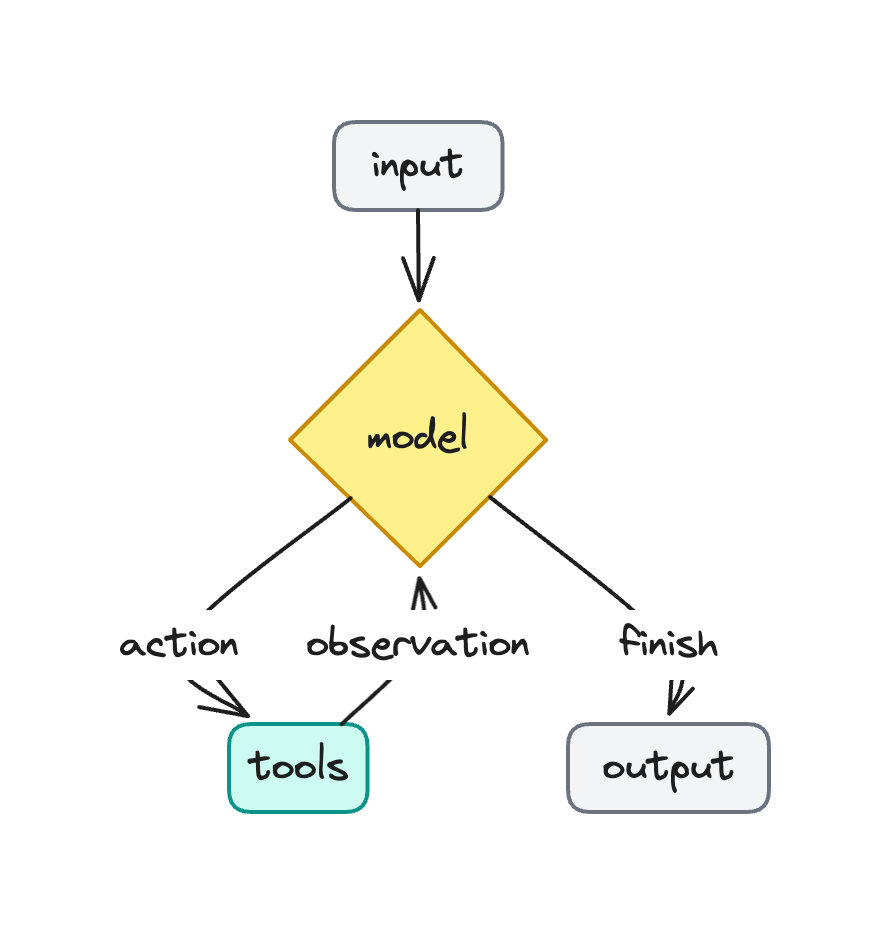

In [21]:
from IPython.display import Image

# 컴파일된 워크플로우 그래프 구조를 확인합니다
Image(filename="assets/01-mcp-workflow-graph.png")

아래 코드는 생성된 MCP 워크플로우를 실행하여 현재 시간을 조회합니다.

In [22]:
# 새로운 대화 스레드 설정
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# MCP 워크플로우 실행: 현재 시간 조회
_ = await astream_graph(
    mcp_app,
    inputs={"messages": [("human", "현재 시간을 알려주세요")]},
    config=config,
)


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Current time in Asia/Seoul is: 2026-03-18 21:44:51 KST
🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
현재 시간은 **2026년 3월 18일 오후 9시 44분 51초 (KST, 한국 표준시)** 입니다.

아래 코드는 MCP 도구(시간 조회)와 Tavily 도구(뉴스 검색)를 조합한 복합 작업을 실행합니다. 에이전트가 시간을 먼저 조회한 후 해당 날짜의 뉴스를 검색하는 과정을 자동으로 수행합니다.

In [23]:
# 복합 작업: 시간 조회 후 뉴스 검색 (Tavily 도구 사용)
_ = await astream_graph(
    mcp_app,
    inputs={
        "messages": [
            ("human", "오늘 뉴스를 검색해주세요. 검색시 시간을 조회한 뒤 처리하세요.")
        ]
    },
    config=config,
)


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Current time in Asia/Seoul is: 2026-03-18 21:44:56 KST
🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "오늘 뉴스 2026년 3월 18일", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.investopedia.com/stock-market-today-dow-jones-s-and-p-500-03172026-11927835", "title": "Markets News, March 17, 2026: Major Indexes End Higher for 2nd Straight Session as Investors Digest War Developments - Investopedia", "score": 0.6742441, "published_date": "Tue, 17 Mar 2026 19:41:01 GMT", "content": "Markets News, March 4, 2026: Major Indexes Close Higher as Stocks Rebound from Sell-Off; Bitcoin, Crypto-Tied Shares Soar. Markets News, March 16, 2026: Major Indexes Close Sharply Higher as Oil Retreats; Dow Rises Nearly 400 Points. Markets New

---

## Part 6: 외부 MCP 서버에서 3rd Party 도구 사용하기

### Context7 MCP 서버

[Context7](https://github.com/upstash/context7)은 최신 프로그래밍 언어 및 프레임워크 문서를 검색하고 제공하는 MCP 서버입니다. LangGraph, React, Python 등의 최신 공식 문서를 실시간으로 검색하여 최신 정보 기반의 코드 생성에 활용할 수 있습니다.

`npx`를 통해 직접 실행할 수 있으며, stdio 전송 방식으로 클라이언트와 통신합니다. [Smithery AI](https://smithery.ai/)와 같은 MCP 서버 레지스트리에서 다양한 3rd Party MCP 서버를 검색하여 동일한 방식으로 사용할 수 있습니다.

아래 코드는 Context7 MCP 서버를 포함한 다중 서버 구성을 설정하고 워크플로우를 생성합니다.

In [24]:
# 다중 MCP 서버 구성 (로컬 + HTTP + Context7)
server_configs = {
    # 로컬 날씨 서버 (stdio)
    "weather": {
        "command": "uv",
        "args": ["run", "python", "server/mcp_server_local.py"],
        "transport": "stdio",
    },
    # 원격 시간 서버 (HTTP)
    "current_time": {
        "url": "http://127.0.0.1:8002/mcp",
        "transport": "streamable_http",
    },
    # Context7 MCP 서버: 최신 문서 검색
    "context7-mcp": {
        "command": "npx",
        "args": ["-y", "@upstash/context7-mcp@latest"],
        "transport": "stdio",
    },
}

# 다중 서버를 사용하는 MCP 워크플로우 생성
mcp_app = await create_mcp_workflow(server_configs)

[MCP] 4개의 도구가 로드되었습니다:
  - get_weather
  - get_current_time
  - resolve-library-id
  - query-docs


아래 코드는 Context7 서버를 활용하여 최신 LangGraph 문서에서 ReAct Agent 관련 내용을 검색하고, 검색된 정보를 바탕으로 Tavily 검색을 수행하는 ReAct Agent 코드를 생성하는 복합 작업을 실행합니다.

In [25]:
# 새로운 대화 스레드 설정
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# Context7 서버를 활용한 복합 작업:
# 1. 최신 LangGraph 문서에서 ReAct Agent 관련 내용 검색
# 2. 검색된 정보를 바탕으로 코드 생성
await astream_graph(
    mcp_app,
    inputs={
        "messages": [
            (
                "human",
                "최신 LangGraph 도큐먼트에서 ReAct Agent 관련 내용을 검색하세요. 그런 다음 Tavily 검색을 수행하는 ReAct Agent를 생성하세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
LangGraph 도큐먼트에서 ReAct Agent 관련 내용을 검색하고, Tavily 검색을 수행하는 ReAct Agent를 생성해드리겠습니다.

먼저 LangGraph의 라이브러리 ID를 찾고 ReAct Agent 관련 문서를 검색하겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Available Libraries:

- Title: LangGraph
- Context7-compatible library ID: /websites/langchain_oss_python_langgraph
- Description: LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents, offering durable execution, human-in-the-loop capabilities, and comprehensive memory.
- Code Snippets: 851
- Source Reputation: High
- Benchmark Score: 86.09
----------
- Title: LangGraph
- Context7-compatible library ID: /langchain-ai/langgraph
- Description: Build resilient language agents as graphs.
- Code Snippets: 241
- Source Reputation: High
- Benchmark Score: 78.37
- Versions: 0.2.74, 0.4.8, 0.5.3, 0.6.0, v0_0_8, 0_6_7, 1.0.3, prebuilt__1.0.4, 1.0.6, 1.0

{'node': 'agent',
 'content': AIMessageChunk(content=[], additional_kwargs={}, response_metadata={'stop_reason': 'end_turn', 'stop_sequence': None, 'model_provider': 'anthropic'}, id='lc_run--019d00fa-c690-7871-98db-12c121d2c32f', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7863, 'output_tokens': 3526, 'total_tokens': 11389, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}}, tool_call_chunks=[], chunk_position='last'),
 'metadata': {'thread_id': '09c1a3eb-fb13-4297-a35d-4940cfb1bda4',
  'langgraph_step': 5,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent',),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:333fe4fe-2ca5-efcf-8926-722d8f79dcc9',
  'checkpoint_ns': 'agent:333fe4fe-2ca5-efcf-8926-722d8f79dcc9',
  'ls_provider': 'anthropic',
  'ls_model_name': 'claude-sonnet-4-5',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'ls_max_tokens': 64000,
  'LANGSMITH_PROJECT': 'LangGraph-V1-